# Starter Notebook: Vision Classification with Digits

This notebook gives a small, runnable starting point for image-based prediction. It uses the scikit-learn digits dataset so students can focus on the workflow before moving to a larger vision dataset.

The main ideas are:

- inspect the images and target labels;
- turn each image into a numeric feature vector;
- compare a trivial reference baseline with simple vision baselines;
- adapt the same scaffold later for other image-classification tasks.

## Before You Start

Write down these choices before you run the modeling cells:

- what is the prediction target?
- what is the simplest reference baseline?
- what is the first useful image representation?
- what metric will you use to compare models?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

## 1. Load a small image dataset

The digits dataset contains small grayscale images of handwritten digits from 0 to 9. Each image is 8 by 8 pixels, so it is small enough to explore quickly in class.

In [2]:
digits = load_digits()
images = digits.images
X = digits.data
y = digits.target

print('Image array shape:', images.shape)
print('Flattened feature table shape:', X.shape)
print('Number of classes:', len(np.unique(y)))
print('Class labels:', np.unique(y))

Image array shape: (1797, 8, 8)
Flattened feature table shape: (1797, 64)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


## 2. Look at a few examples

Before building features or fitting a model, inspect the images. This helps you understand image size, grayscale intensity, and variation across classes.

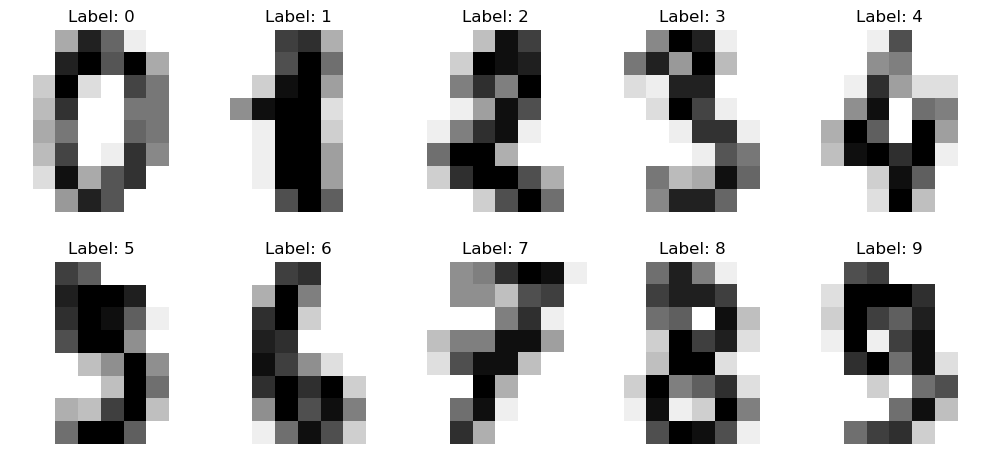

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), images[:10], y[:10]):
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Understand the representation

For a conventional model such as logistic regression, we need a numeric feature table. Here, the simplest representation is to flatten each 8 by 8 image into 64 pixel-intensity values.

That is already done for us in `digits.data`, where each row is one image and each column is one pixel position.

In [4]:
pixel_df = pd.DataFrame(X)
pixel_df['label'] = y
display(pixel_df.head())

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 4. Train-test split

We will keep a test set separate so we can compare models fairly.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])

Training rows: 1437
Test rows: 360


## 5. Reference baseline

A trivial reference model for classification can always predict the most common class. It is a weak model, but it tells us whether our first real model is learning anything useful.

In [6]:
reference_model = DummyClassifier(strategy='most_frequent')
reference_model.fit(X_train, y_train)
reference_predictions = reference_model.predict(X_test)

reference_accuracy = accuracy_score(y_test, reference_predictions)
print('Reference baseline accuracy:', round(reference_accuracy, 3))

Reference baseline accuracy: 0.1


## 6. First conventional baseline: logistic regression

This is a strong first baseline for small image problems when the images are already aligned and the task is classification. It treats the flattened pixels as numeric input features.

In [8]:
logreg_model = LogisticRegression(max_iter=3000)
logreg_model.fit(X_train, y_train)
logreg_predictions = logreg_model.predict(X_test)

logreg_accuracy = accuracy_score(y_test, logreg_predictions)
print('Logistic regression accuracy:', round(logreg_accuracy, 3))

Logistic regression accuracy: 0.958


## 7. Optional comparison model: random forest

A tree-based model gives a useful contrast with logistic regression. It can capture nonlinear interactions between pixels, although it may be slower and need more tuning on larger image tasks.

In [9]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print('Random forest accuracy:', round(rf_accuracy, 3))

Random forest accuracy: 0.969


## 8. Compare the models

The point is not to chase the highest score immediately. The point is to compare a trivial reference with one or two sensible conventional models and understand what your representation is already achieving.

In [10]:
results_df = pd.DataFrame(
    {
        'model': ['Most frequent class', 'Logistic Regression', 'Random Forest'],
        'accuracy': [reference_accuracy, logreg_accuracy, rf_accuracy],
    }
)
results_df = results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy
0,Random Forest,0.969444
1,Logistic Regression,0.958333
2,Most frequent class,0.100000


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       0.97      1.00      0.99        35
           3       0.95      1.00      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.86      0.86      0.86        35
           9       1.00      0.94      0.97        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



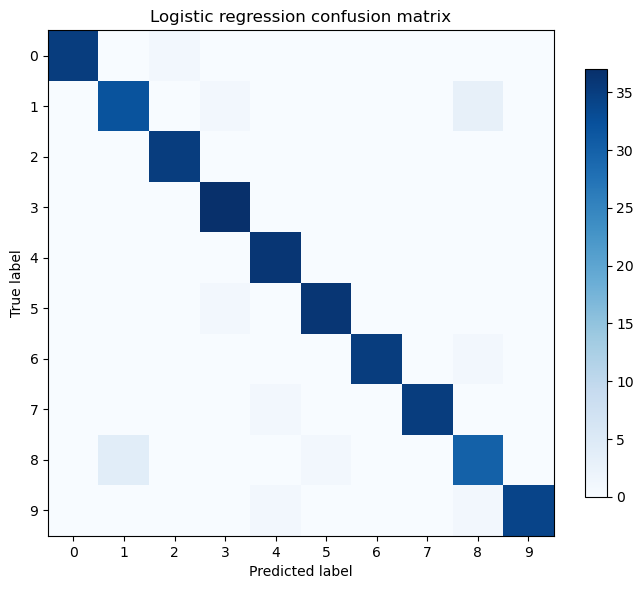

In [11]:
print(classification_report(y_test, logreg_predictions))
cm = confusion_matrix(y_test, logreg_predictions)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Logistic regression confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 9. How to adapt this notebook to your own images

For your own vision task, replace the built-in digits dataset with your real images. A practical first version is often:

- resize all images to the same shape;
- convert to grayscale if colour is not essential;
- flatten the resized image into a feature vector for a classical baseline;
- compare against a trivial classifier;
- only then consider transfer learning or a CNN.

If your dataset is very small, start with a handful of classes and make sure the pipeline runs end to end before increasing complexity.

In [ ]:
# TEMPLATE FOR YOUR OWN IMAGE FOLDER
# Uncomment and adapt when you are ready to use your own data.
#
# from pathlib import Path
# from PIL import Image
#
# image_dir = Path('data/your_image_folder')
# class_names = sorted([p.name for p in image_dir.iterdir() if p.is_dir()])
#
# X_images = []
# y_labels = []
#
# for class_name in class_names:
#     for image_path in (image_dir / class_name).glob('*'):
#         image = Image.open(image_path).convert('L').resize((32, 32))
#         X_images.append(np.asarray(image).reshape(-1))
#         y_labels.append(class_name)
#
# X_images = np.asarray(X_images)
# y_labels = np.asarray(y_labels)
# print('Loaded rows:', X_images.shape[0])
# print('Feature width:', X_images.shape[1])

## 10. Takeaways

- A small built-in dataset is useful for learning the workflow before moving to your own files.
- Flattened pixels are a simple starter representation for conventional models.
- Always compare against a trivial reference baseline.
- Once the end-to-end classical pipeline works, you can decide whether transfer learning or CNNs are justified.